# SkinTell — 03 Modeling
Train a skin condition severity classifier using transfer learning with MobileNetV2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

CLEAN_DIR  = '../data/processed'
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
CLASS_LABELS = ['clear', 'mild', 'moderate', 'severe']

print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.21.0
GPU available: False


## 1. Data Generators

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=20, horizontal_flip=True,
    brightness_range=[0.8, 1.2], zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    CLEAN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
val_gen = val_datagen.flow_from_directory(
    CLEAN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)

class_weights = compute_class_weight('balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', {CLASS_LABELS[k]: round(v, 3) for k, v in class_weight_dict.items()})

Found 1103 images belonging to 4 classes.
Found 274 images belonging to 4 classes.
Class weights: {'clear': np.float64(0.713), 'mild': np.float64(0.553), 'moderate': np.float64(1.97), 'severe': np.float64(3.581)}


## 2. Build Model — MobileNetV2 Transfer Learning

In [3]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Phase 1 — Train Top Layers (base frozen)

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('../models/best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3218 - loss: 1.5092 - val_accuracy: 0.3832 - val_loss: 1.2418 - learning_rate: 0.0010
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.3998 - loss: 1.1596 - val_accuracy: 0.4672 - val_loss: 1.1353 - learning_rate: 0.0010
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 395ms/step - accuracy: 0.4533 - loss: 1.0591 - val_accuracy: 0.3650 - val_loss: 1.1797 - learning_rate: 0.0010
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 707ms/step - accuracy: 0.4633 - loss: 1.0263 - val_accuracy: 0.4526 - val_loss: 1.1465 - learning_rate: 0.0010
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 891ms/step - accuracy: 0.4597 - loss: 0.9421 - val_accuracy: 0.4745 - val_loss: 1.1071 - learning_rate: 0.0010
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 875ms/step - accuracy: 0.5131 - loss: 0.9157 - val_accuracy: 0.4708 - val_loss: 1.1216 - learning_rate: 0.0010
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 653ms/step - accuracy: 0.5023 - loss: 0.904

## 4. Phase 2 — Fine-tune Top Layers of Base Model

In [5]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 525ms/step - accuracy: 0.4733 - loss: 0.9795 - val_accuracy: 0.5219 - val_loss: 1.0408 - learning_rate: 1.0000e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 811ms/step - accuracy: 0.5322 - loss: 0.8309 - val_accuracy: 0.4489 - val_loss: 1.2307 - learning_rate: 1.0000e-04
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 890ms/step - accuracy: 0.5911 - loss: 0.7078 - val_accuracy: 0.4416 - val_loss: 1.3566 - learning_rate: 1.0000e-04
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 843ms/step - accuracy: 0.6228 - loss: 0.6443 - val_accuracy: 0.4854 - val_loss: 1.2102 - learning_rate: 5.0000e-05
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 874ms/step - accuracy: 0.6310 - loss: 0.6405 - val_accuracy: 0.4635 - val_loss: 1.2718 - learning_rate: 5.0000e-05


## 5. Plot Training History

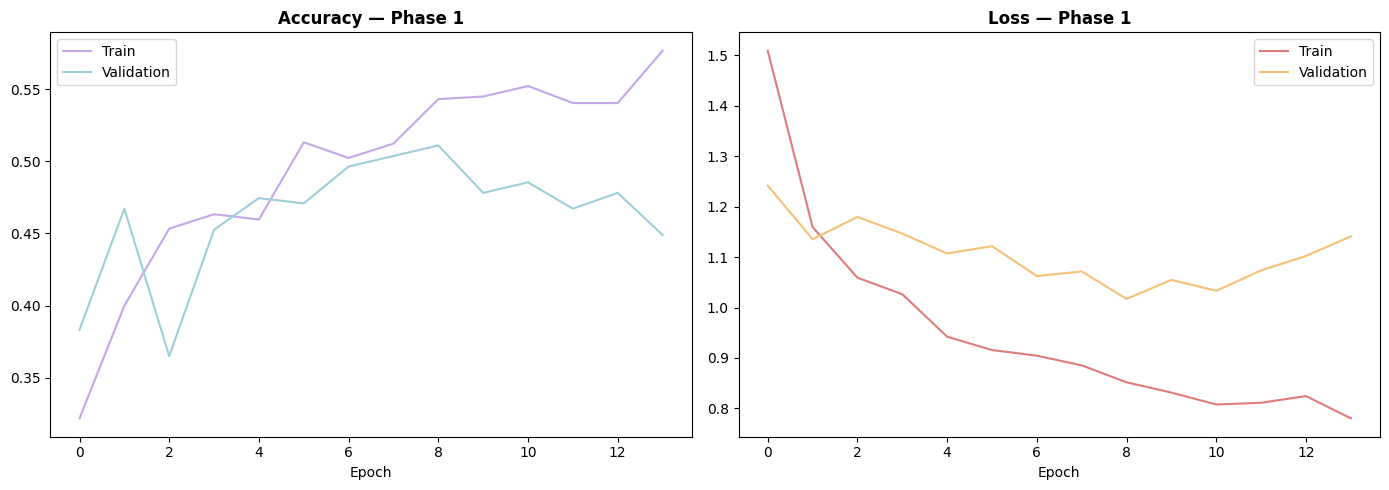

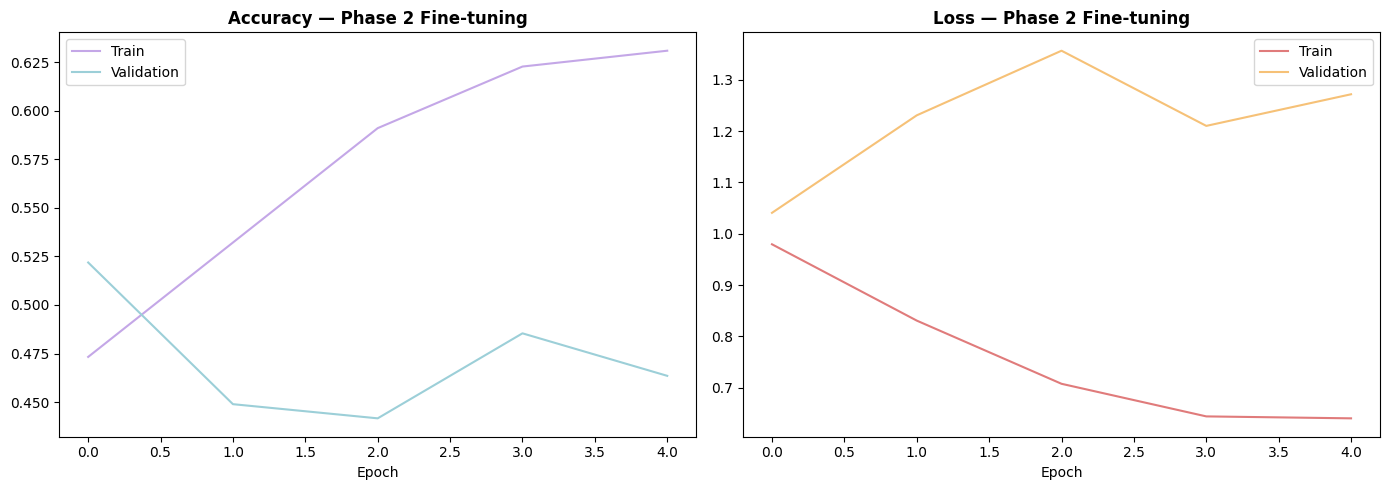

In [6]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train', color='#c4a7e7')
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='#9ccfd8')
    axes[0].set_title(f'Accuracy — {title}', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train', color='#e07b7b')
    axes[1].plot(history.history['val_loss'], label='Validation', color='#f6c177')
    axes[1].set_title(f'Loss — {title}', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'../plots/history_{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

plot_history(history1, 'Phase 1')
plot_history(history2, 'Phase 2 Fine-tuning')